***Mall Customer Segmentation Clustering 🛍️📊*** 

In [1]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

c:\Users\Dilsh\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", lambda x: "%.2f" % x)
sns.set_theme(style='darkgrid')

plt.rcParams.update(
    {
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,

    }
)

CSV_PATH = "../data set/Mall_Customers.csv"

load data set

In [3]:
df=pd.read_csv(CSV_PATH)

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


EDA

In [5]:
#drop the CustomerID column as it is not relevant for clustering
#df.drop(columns=['CustomerID'], inplace=True)

Customer_ID=df['CustomerID']

In [6]:
df.drop(columns=['CustomerID'], inplace=True)


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 7.4 KB


In [8]:
#check for missing values
df.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
#check duplicate values
df.duplicated().sum()

np.int64(0)

Data Visualization

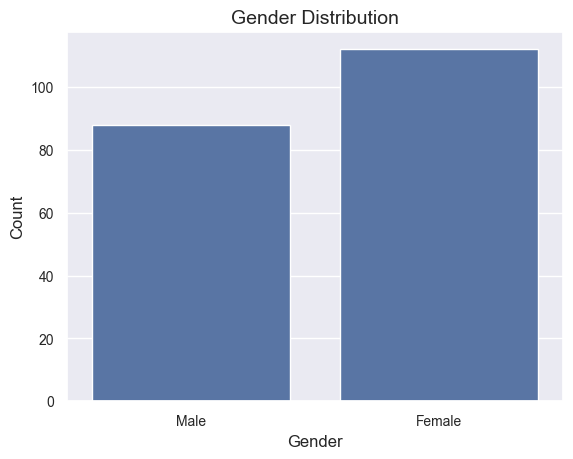

In [10]:
plt.Figure(figsize=(5, 3))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count') 
plt.show()


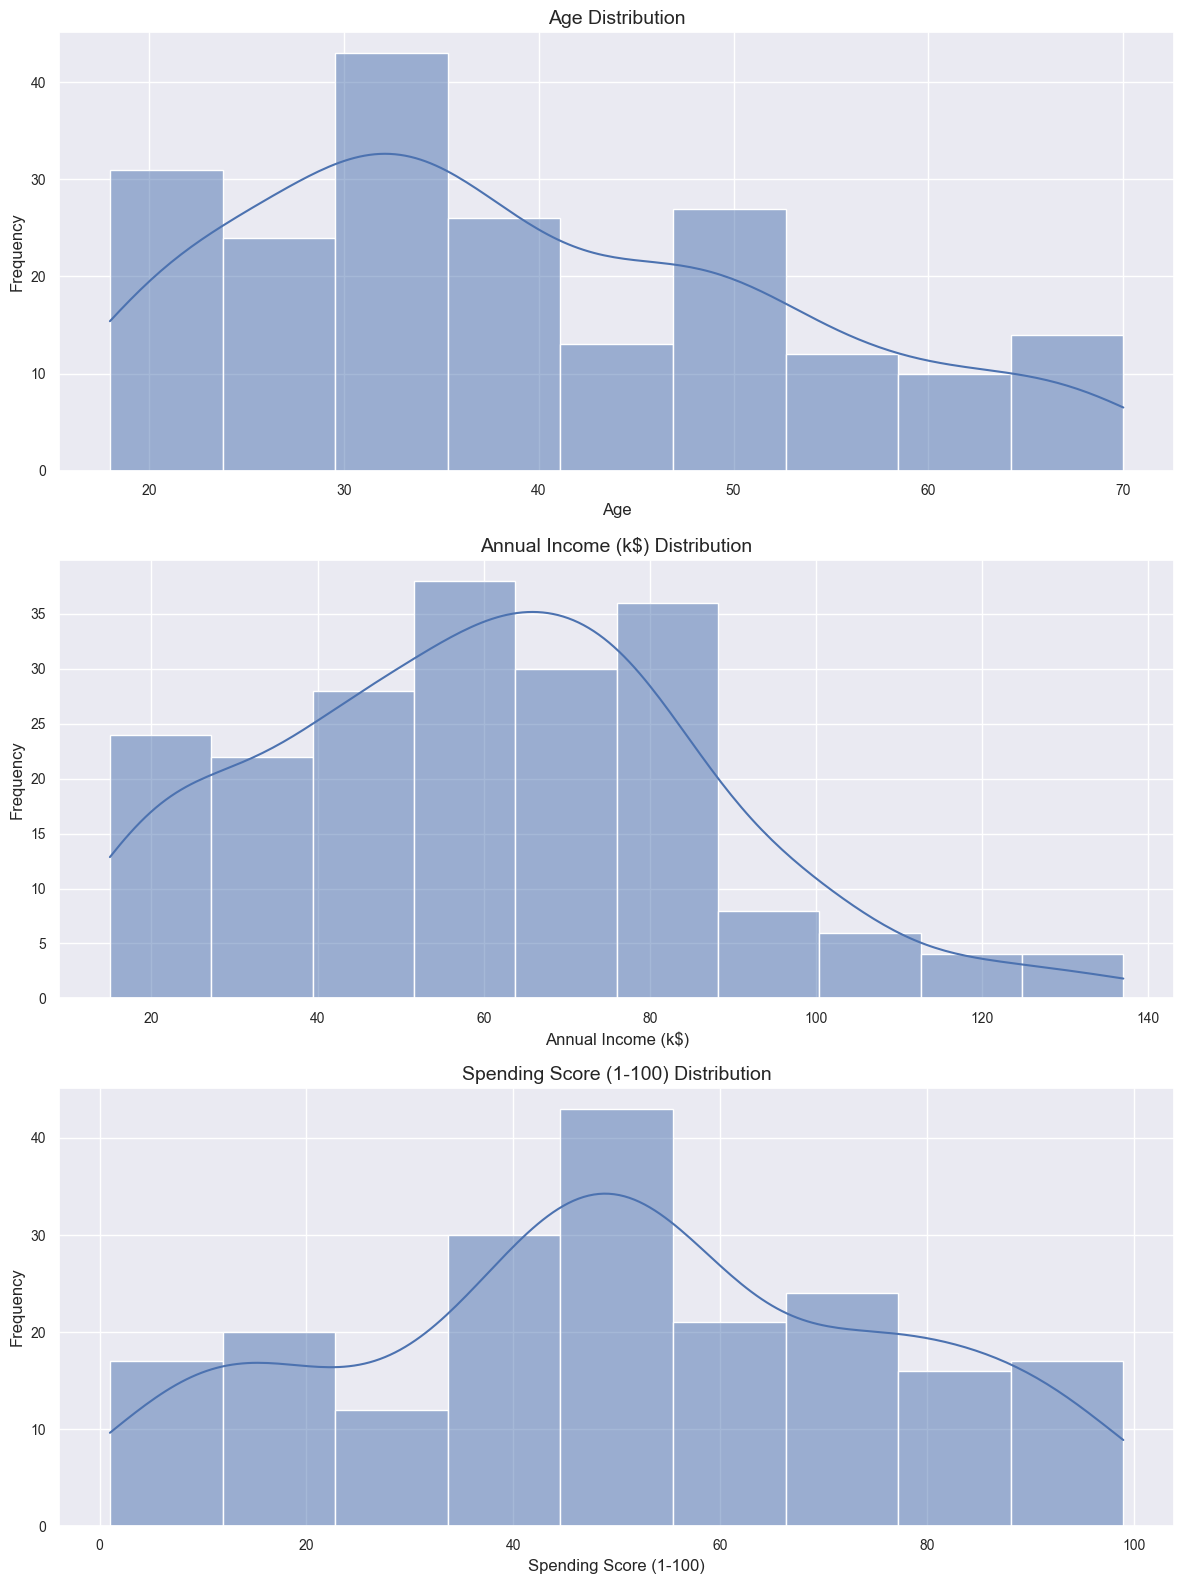

In [11]:
#histogram distribution of Age, Annual Income and Spending Score
fig,axes=plt.subplots(3,1, figsize=(12,16))
axes=axes.flatten()

for i,col in enumerate(df.columns[1:4]):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

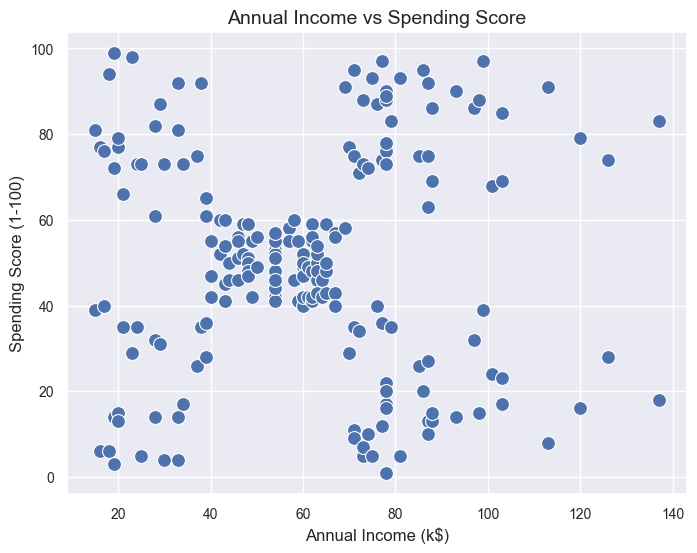

In [12]:
#scatter plot of Annual Income vs Spending Score
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)', 
                data=df,
                s=100)
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()


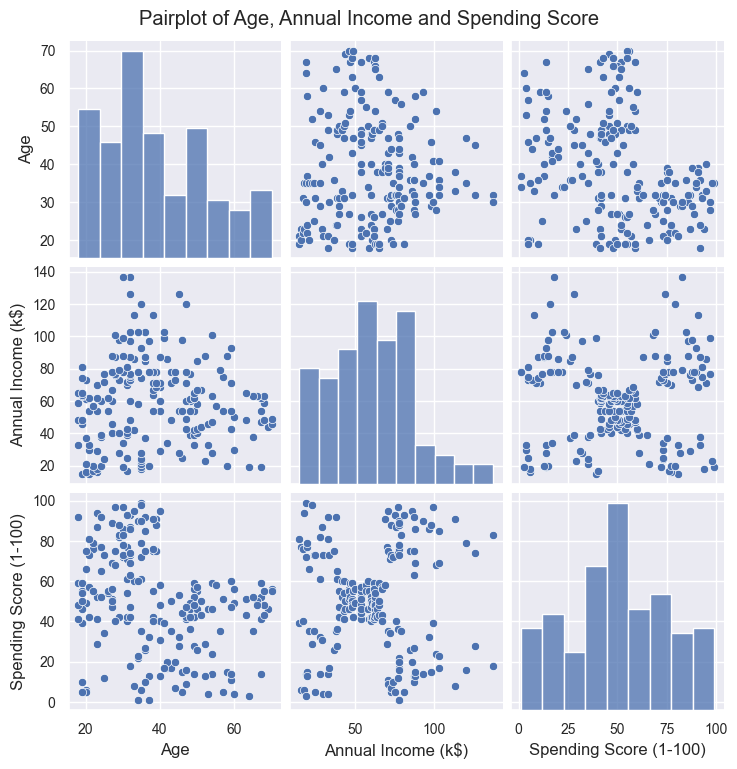

In [13]:
#pairplot of Age, Annual Income and Spending Score
sns.pairplot(df.iloc[:,1:4])
plt.suptitle('Pairplot of Age,' \
            ' Annual Income and Spending Score', 
            y=1.02)
plt.show()


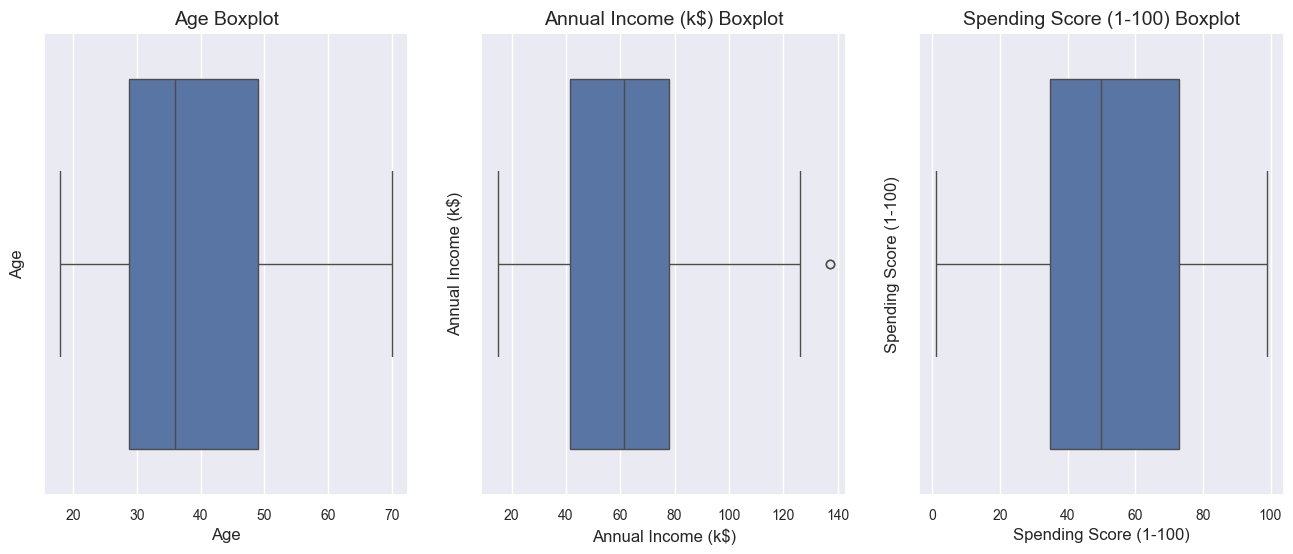

In [14]:
#boxplot of Age, Annual Income and Spending Score
fig,axes=plt.subplots(1,3, figsize=(16,6))
axes=axes.flatten()
for i,col in enumerate(df.columns[1:4]):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'{col} Boxplot')
    axes[i].set_ylabel(col)

In [15]:
#check outliers in Age, Annual Income and Spending Score
for col in df.columns[1:4]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    #sum of outliers
    print(f'{col} Outliers: {outliers.shape[0]}')


Age Outliers: 0
Annual Income (k$) Outliers: 2
Spending Score (1-100) Outliers: 0


In [ ]:
#remove outliers in Annual Income column

for col in df.columns[2:5]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

Text(0.5, 1.0, 'Correlation Heatmap')

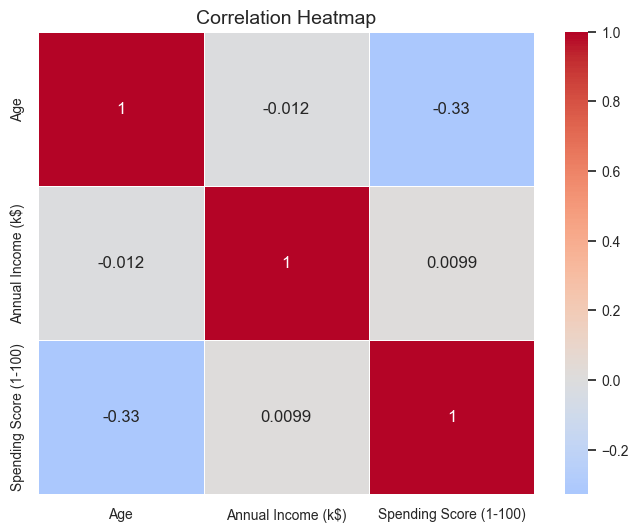

In [16]:
#heatmap of correlation between Age, Annual Income and Spending Score
plt.figure(figsize=(8,6))
sns.heatmap(df.iloc[:,1:4].corr(), annot=True, cmap='coolwarm', linewidths=0.5, center=0)
plt.title('Correlation Heatmap')

Data Preprocesing

In [17]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

In [18]:
#feature scaling using StandardScaler
columns_to_scale = ['Annual Income (k$)', 'Spending Score (1-100)']
X=df[columns_to_scale]
#SCALE THE FEATURES 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [19]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

Elbow Method - WCSS

In [20]:
#find the optimal number of clusters using the elbow method
wcss = []
k_range = range(1, 11)



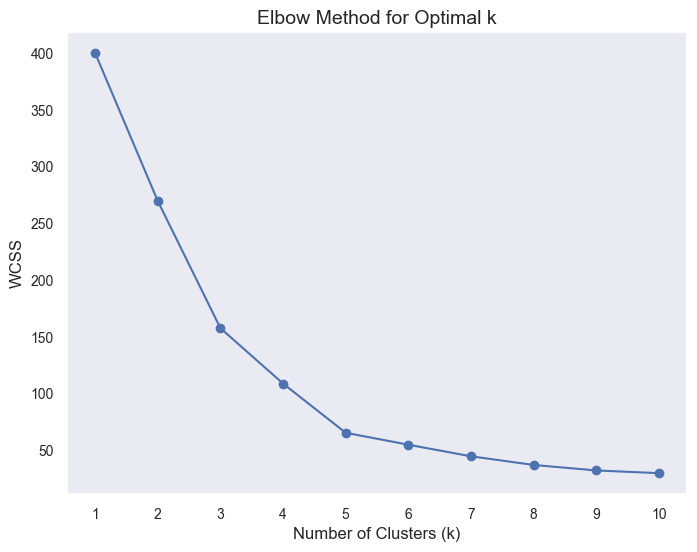

In [21]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(list(k_range), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(list(k_range))
plt.grid()
plt.show()

In [22]:
wcss

[399.99999999999994,
 269.69101219276394,
 157.70400815035947,
 108.92131661364357,
 65.56840815571681,
 55.057348270386,
 44.86475569922557,
 37.228187677585886,
 32.39226763033116,
 29.981897788243696]

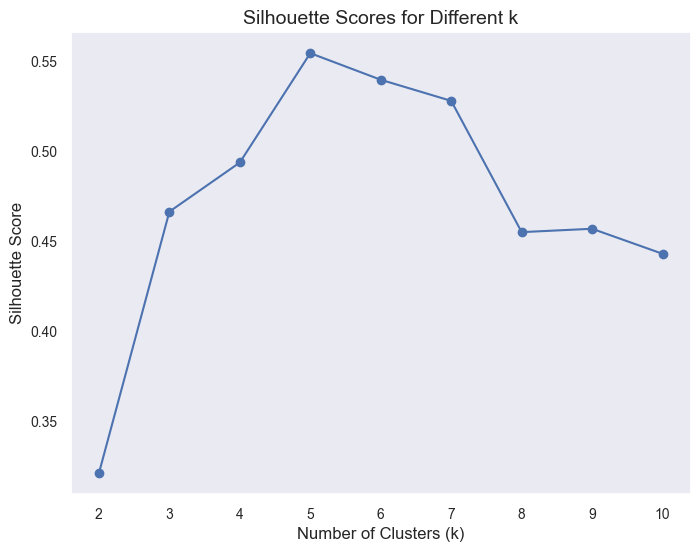

In [23]:
#identify the optimal number of clusters using silhouette score
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
plt.figure(figsize=(8,6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid()
plt.show()


In [24]:
k_values =5

In [25]:
#fit the KMeans model with the optimal number of clusters
kmeans = KMeans(n_clusters=k_values, 
                random_state=42, 
                n_init=10
)

In [26]:
kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [27]:
clusters=kmeans.predict(X_scaled)

In [28]:
clusters

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [29]:
#copy of the original dataframe with cluster labels
df_clusters = df.copy(deep=True)

In [30]:
df_clusters

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [31]:
df_clusters['Cluster'] = clusters
df_clusters

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4
...,...,...,...,...,...
195,Female,35,120,79,1
196,Female,45,126,28,3
197,Male,32,126,74,1
198,Male,32,137,18,3


In [32]:
#ADD CustomerID back to the clustered dataframe
df_clusters['CustomerID'] = Customer_ID
df_clusters

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,CustomerID
0,Male,19,15,39,4,1
1,Male,21,15,81,2,2
2,Female,20,16,6,4,3
3,Female,23,16,77,2,4
4,Female,31,17,40,4,5
...,...,...,...,...,...,...
195,Female,35,120,79,1,196
196,Female,45,126,28,3,197
197,Male,32,126,74,1,198
198,Male,32,137,18,3,199


Evaluation

In [33]:
k_means_score = silhouette_score(X_scaled, df_clusters['Cluster'])
print(f'Silhouette Score for KMeans with k={k_values}: {k_means_score:.4f}')   

Silhouette Score for KMeans with k=5: 0.5547


Visualize the clusters

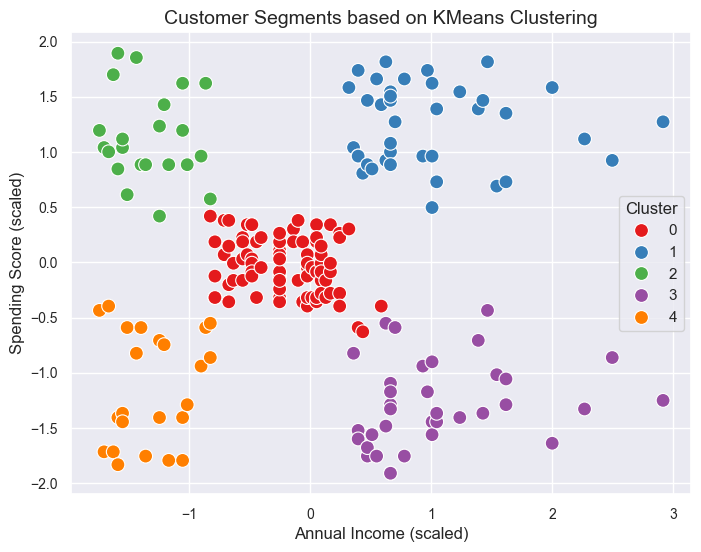

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:,0], 
                y=X_scaled[:,1], 
                hue=df_clusters['Cluster'], 
                palette='Set1', 
                s=100)
plt.title('Customer Segments based on KMeans Clustering')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.legend(title='Cluster')
plt.show()

Cluster Interpretaion

In [35]:
df.columns


Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

In [ ]:
profile_col=['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

cluster_size=df_clusters['Cluster'].value_counts().sort_index()
print(cluster_size)
print("-" * 100)

cluster_profile = df_clusters.groupby('Cluster')[profile_col].mean()
print(cluster_profile)

cluster_profile_median = df_clusters.groupby('Cluster')[profile_col].median()   
print("-" * 100)
print(cluster_profile_median)



Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0       42.72               55.30                   49.52
1       32.69               86.54                   82.13
2       25.27               25.73                   79.36
3       41.11               88.20                   17.11
4       45.22               26.30                   20.91
----------------------------------------------------------------------------------------------------
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0       46.00               54.00                   50.00
1       32.00               79.00                   83.00
2       23.50               24.50                   77.00
3       42.00               

Segment new customet

In [46]:
# new customer segmentation code


def assign_cluster_segment(income_k, spending_score,scaler, model):

    new_point = pd.DataFrame(
        [(income_k, spending_score)],
        columns=['Annual Income (k$)', 'Spending Score (1-100)']
    )

    new_point_scaled = scaler.transform(new_point)

    cluster_id = model.predict(new_point_scaled)[0]

    return cluster_id



In [48]:
#new customer data
new_customer=assign_cluster_segment(50, 100, scaler, kmeans)
print(f'New customer belongs to Cluster: {new_customer}')

New customer belongs to Cluster: 2
